# Масштабирование продаж товаров маркетплейса

## Импорт бибилиотек и загрузка данных

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors

In [3]:
# Загрузка данных
path_to_file = 'C:/Users/Vi/Desktop/Мои проекты/Проект 4. Когортный анализ маркетплейса/olist_customers_dataset.csv'
customers = pd.read_csv(path_to_file)

In [5]:
path_to_file2 = 'C:/Users/Vi/Desktop/Мои проекты/Проект 4. Когортный анализ маркетплейса/olist_order_items_dataset.csv'
order_items = pd.read_csv(path_to_file2)

In [7]:
path_to_file3 = 'C:/Users/Vi/Desktop/Мои проекты/Проект 4. Когортный анализ маркетплейса/olist_orders_dataset.csv'
orders = pd.read_csv(path_to_file3)

In [9]:
# Проверка загруженных данных
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [11]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [13]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Оценка месячного retention в оформление заказа с помощью когортного анализа

In [16]:
# Объединение таблицы для удобства анализа
data = pd.merge(
    customers[['customer_id', 'customer_unique_id']],
    orders[['customer_id', 'order_purchase_timestamp', 'order_status']],
    on='customer_id',
    how='inner')
data

,customer_id,customer_unique_id,order_purchase_timestamp,order_status
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,2017-05-16 15:05:35,delivered
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,2018-01-12 20:48:24,delivered
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,2018-05-19 16:07:45,delivered
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,2018-03-13 16:06:38,delivered
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,2018-07-29 09:51:30,delivered
...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,2018-04-07 15:48:17,delivered
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,2018-04-04 08:20:22,delivered
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,2018-04-08 20:11:50,delivered
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,2017-11-03 21:08:33,delivered


In [18]:
# Определение группы клиентов (когорт)
# Находим первую покупку каждого пользователя
first_purchase = data.groupby('customer_unique_id')['order_purchase_timestamp'].min()
# Фильтруем доставленные заказы
delivered_orders = data[data['order_status'] == 'delivered'].copy()

In [20]:
# Поиск первой покупки каждого пользователя
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(delivered_orders['order_purchase_timestamp'])
first_purchase = delivered_orders.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'date_1st_purchase']
first_purchase['C_month'] = first_purchase['date_1st_purchase'].dt.to_period('M')

In [24]:
# Создаем основную таблицу для анализа
# Для этого объединяем все заказы с информацией о первой покупке
data_cohort = pd.merge(
    delivered_orders,
    first_purchase[['customer_unique_id', 'date_1st_purchase', 'C_month']],
    on='customer_unique_id',
    how='left')
# Считаем разницу в месяцах
data_cohort['days_diff'] = (
    data_cohort['order_purchase_timestamp'] - data_cohort['date_1st_purchase']).dt.days
data_cohort['periods_diff'] = np.floor(data_cohort['days_diff'] / 30).astype(int)
data_cohort

,customer_id,customer_unique_id,order_purchase_timestamp,order_status,date_1st_purchase,C_month,days_diff,periods_diff
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,2017-05-16 15:05:35,delivered,2017-05-16 15:05:35,2017-05,0,0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,2018-01-12 20:48:24,delivered,2018-01-12 20:48:24,2018-01,0,0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,2018-05-19 16:07:45,delivered,2018-05-19 16:07:45,2018-05,0,0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,2018-03-13 16:06:38,delivered,2018-03-13 16:06:38,2018-03,0,0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,2018-07-29 09:51:30,delivered,2018-07-29 09:51:30,2018-07,0,0
...,...,...,...,...,...,...,...,...
96473,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,2018-04-07 15:48:17,delivered,2018-04-07 15:48:17,2018-04,0,0
96474,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,2018-04-04 08:20:22,delivered,2018-04-04 08:20:22,2018-04,0,0
96475,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,2018-04-08 20:11:50,delivered,2018-04-08 20:11:50,2018-04,0,0
96476,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,2017-11-03 21:08:33,delivered,2017-11-03 21:08:33,2017-11,0,0


In [26]:
# Проверяем, что months_diff не равны нулю
print(f"Минимальная разница в месяцах: {data_cohort['periods_diff'].min()}")
print(f"Максимальная разница в месяцах: {data_cohort['periods_diff'].max()}")

Минимальная разница в месяцах: 0
Максимальная разница в месяцах: 21


In [28]:
# Исследуем, что получилось
data_cohort['periods_diff'].value_counts()

periods_diff
0     94837
1       328
2       239
3       183
4       160
5       141
6       122
7        93
8        77
9        74
11       56
10       53
13       31
12       27
14       23
15       12
16        9
17        8
19        3
20        1
21        1
Name: count, dtype: int64

In [30]:
data_cohort.nunique()

customer_id                 96478
customer_unique_id          93358
order_purchase_timestamp    95956
order_status                    1
date_1st_purchase           93115
C_month                        23
days_diff                     426
periods_diff                   21
dtype: int64

In [32]:
# Группируем для таблицы retention
retention_table = data_cohort.groupby(['C_month', 'periods_diff'])['customer_unique_id'].nunique().reset_index()
retention_table.columns = ['C_month', 'periods_diff', 'user_count']
# Создаем таблицу
retention_matrix = retention_table.pivot(
    index='C_month',
    columns='periods_diff',
    values='user_count')
# Проводим нормализацию. Для каждой когорты Month 0 = 100%
retention_matrix_nz = (retention_matrix.div(retention_matrix[0], axis=0)*100).round(2)
retention_matrix_nz
# Заменяем NaN нулями
retention_matrix_filled = retention_matrix_nz.fillna(0)
retention_matrix_filled

periods_diff,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,19,20,21
C_month,,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10,100.0,0.00,0.00,0.00,0.00,0.00,0.38,0.00,0.00,0.38,...,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.76,0.38,0.38
2016-12,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01,100.0,0.28,0.00,0.56,0.14,0.14,0.28,0.28,0.00,0.00,...,0.56,0.42,0.28,0.00,0.28,0.28,0.28,0.14,0.00,0.00
2017-02,100.0,0.12,0.18,0.37,0.25,0.12,0.25,0.06,0.12,0.31,...,0.37,0.06,0.18,0.12,0.06,0.06,0.18,0.00,0.00,0.00
2017-03,100.0,0.28,0.52,0.44,0.12,0.08,0.36,0.16,0.28,0.24,...,0.16,0.16,0.12,0.28,0.08,0.12,0.08,0.00,0.00,0.00
2017-04,100.0,0.35,0.27,0.04,0.27,0.35,0.27,0.44,0.27,0.22,...,0.13,0.00,0.09,0.09,0.09,0.09,0.00,0.00,0.00,0.00
2017-05,100.0,0.43,0.38,0.23,0.38,0.32,0.32,0.12,0.29,0.26,...,0.32,0.17,0.09,0.20,0.12,0.00,0.00,0.00,0.00,0.00
2017-06,100.0,0.43,0.53,0.33,0.20,0.49,0.30,0.20,0.13,0.33,...,0.26,0.10,0.30,0.13,0.00,0.00,0.00,0.00,0.00,0.00


In [34]:
# Медианный retention 1-го месяца
median_month1_retention = retention_matrix_filled[1].median()
# Когорта с максимальным retention на 3-й месяц
best_cohort_month3 = retention_matrix_filled[3].idxmax()
best_value_month3 = retention_matrix_filled[3].max()

print(f"Медианный retention 1-го месяца: {median_month1_retention:.2f}%")
print(f"Лучшая когорта на 3-й месяц: {best_cohort_month3} с retention {best_value_month3:.2f}%")

Медианный retention 1-го месяца: 0.35%
Лучшая когорта на 3-й месяц: 2017-01 с retention 0.56%


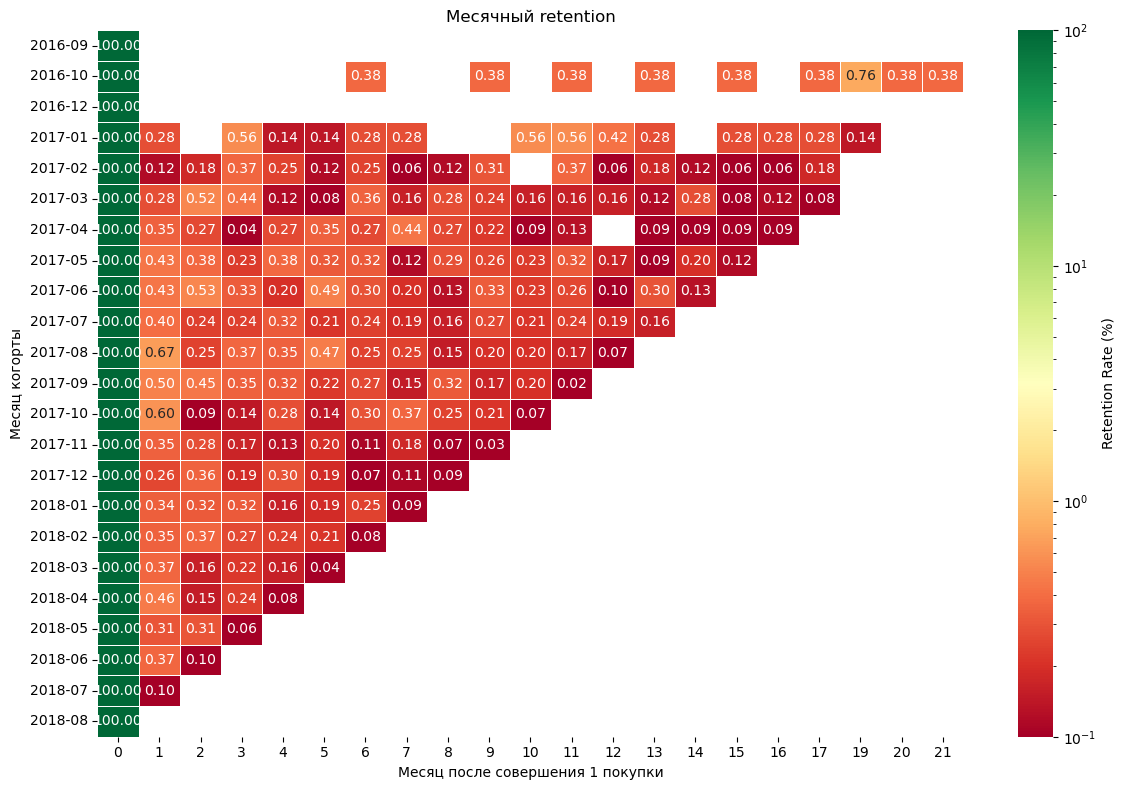

In [36]:
norm = colors.LogNorm(vmin=0.1, vmax=100)
# Создаем Heatmap для retention
plt.figure(figsize=(12, 8))
sns.heatmap(
    retention_matrix_filled,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    norm=norm,
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title('Месячный retention')
plt.xlabel('Месяц после совершения 1 покупки')
plt.ylabel('Месяц когорты')
plt.tight_layout()
plt.show()

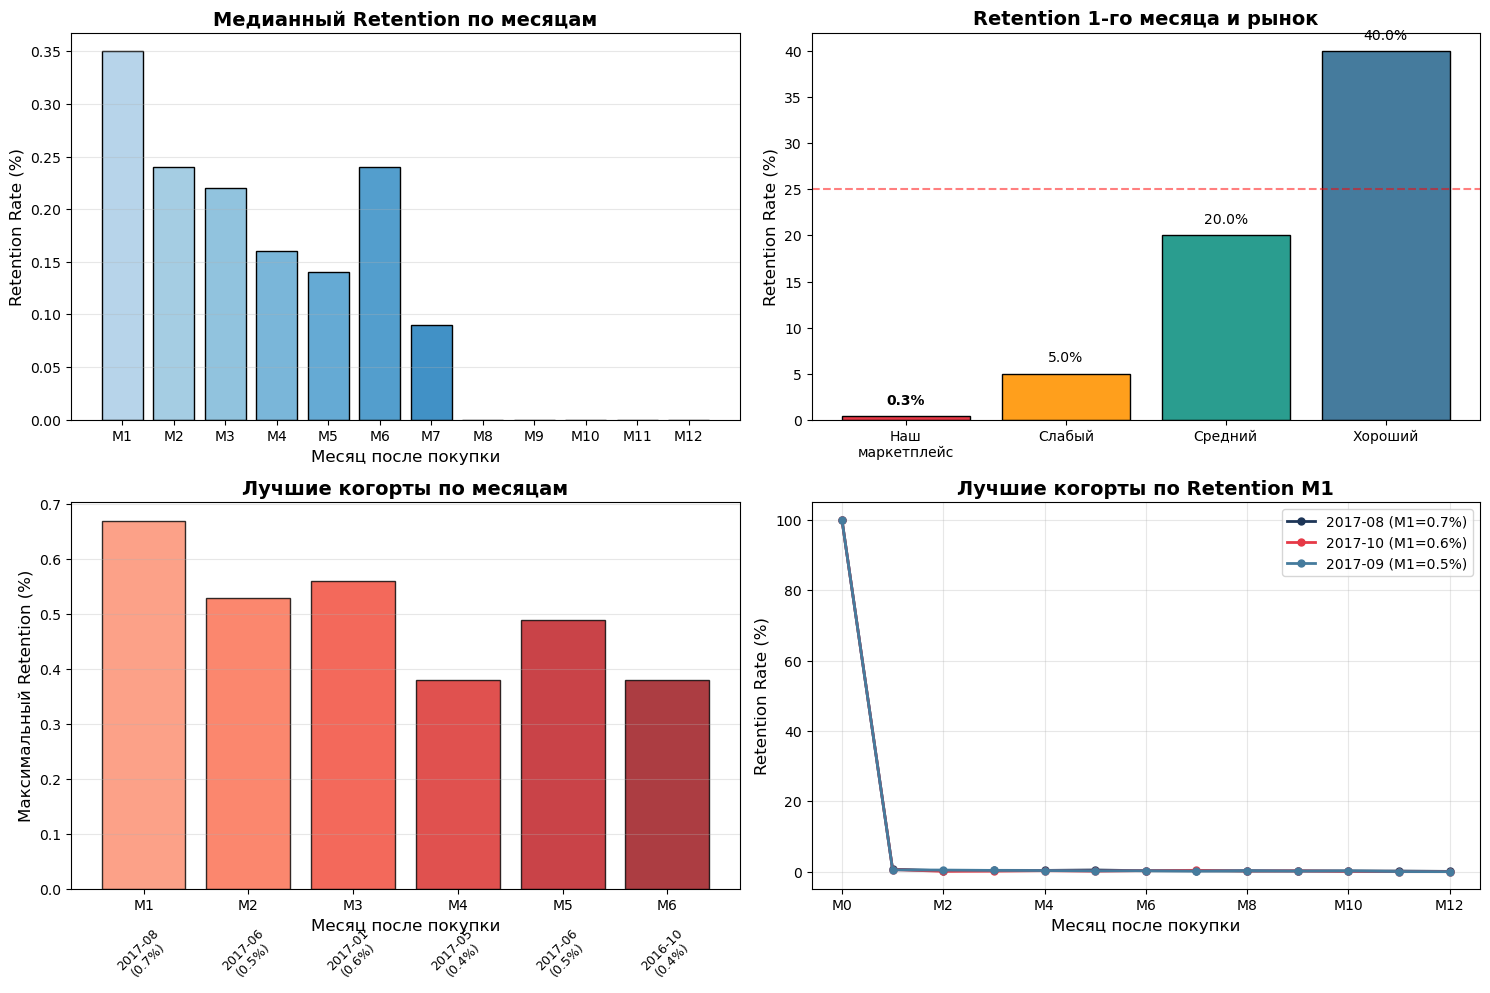

Когорты с максимальным retention по месяцам:
M1: 2017-08 - 0.67%
M2: 2017-06 - 0.53%
M3: 2017-01 - 0.56%
M4: 2017-05 - 0.38%
M5: 2017-06 - 0.49%
M6: 2016-10 - 0.38%
Лучшая когорта в целом: 2017-01 (M3=0.56%)
Отставание от рынка: 24.6% пунктов


<Figure size 640x480 with 0 Axes>

Retention M1 (медиана): 0.3%
Лучшая когорта: 2017-01 (M3=0.6%)


In [38]:
# Отрисовываем графики
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
(ax1, ax2), (ax3, ax4) = axes

# ГРАФИК 1: Медианный Retention по месяцам
# Исключаем месяц 0 (базовый)
median_by_month = retention_matrix_filled.median()
available_months = [m for m in median_by_month.index if m > 0][:12]
median_values = median_by_month.loc[available_months].values

bars = ax1.bar(range(len(available_months)), median_values,
               color=plt.cm.Blues(np.linspace(0.3, 0.9, len(available_months))),
               edgecolor='black')

ax1.set_title('Медианный Retention по месяцам', fontsize=14, fontweight='bold')
ax1.set_xlabel('Месяц после покупки', fontsize=12)
ax1.set_ylabel('Retention Rate (%)', fontsize=12)
ax1.set_xticks(range(len(available_months)))
ax1.set_xticklabels([f'M{m}' for m in available_months])
ax1.grid(True, alpha=0.3, axis='y')

# ГРАФИК 2: Сравнение с бенчмарками
benchmarks = {
    'Наш\nмаркетплейс': median_month1_retention,
    'Слабый': 5.0,
    'Средний': 20.0,
    'Хороший': 40.0
}
categories = list(benchmarks.keys())
values = list(benchmarks.values())
colors = ['#E63946', '#FF9F1C', '#2A9D8F', '#457B9D']

bars = ax2.bar(categories, values, color=colors, edgecolor='black')
ax2.set_title('Retention 1-го месяца и рынок', fontsize=14, fontweight='bold')
ax2.set_ylabel('Retention Rate (%)', fontsize=12)
ax2.axhline(y=25, color='red', linestyle='--', alpha=0.5, label='Цель')

for i, (bar, val) in enumerate(zip(bars, values)):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold' if i == 0 else 'normal')

# ГРАФИК 3: Когорты с максимальным retention по месяцам
# Находим лучшую когорту для каждого месяца
months_to_analyze = [m for m in retention_matrix_filled.columns if 1 <= m <= 6]  # Анализируем первые 6 месяцев

best_cohorts_by_month = []
best_values_by_month = []
cohort_names_by_month = []

for month in months_to_analyze:
    # Исключаем когорты с нулевыми значениями в этом месяце
    month_data = retention_matrix_filled[month]
    non_zero_data = month_data[month_data > 0]

    if len(non_zero_data) > 0:
        # Находим максимальное значение и когорту
        max_value = non_zero_data.max()
        best_cohort = non_zero_data.idxmax()
        best_cohorts_by_month.append(best_cohort)
        best_values_by_month.append(max_value)
        cohort_names_by_month.append(f'{best_cohort}\n({max_value:.1f}%)')
    else:
        # Если все нули
        best_cohorts_by_month.append(None)
        best_values_by_month.append(0)
        cohort_names_by_month.append('Нет данных')

# Создаем bar chart
x_positions = range(len(months_to_analyze))
bars3 = ax3.bar(x_positions, best_values_by_month,
                color=plt.cm.Reds(np.linspace(0.4, 0.9, len(months_to_analyze))),
                edgecolor='black', alpha=0.8)

ax3.set_title('Лучшие когорты по месяцам', fontsize=14, fontweight='bold')
ax3.set_xlabel('Месяц после покупки', fontsize=12)
ax3.set_ylabel('Максимальный Retention (%)', fontsize=12)
ax3.set_xticks(x_positions)
ax3.set_xticklabels([f'M{month}' for month in months_to_analyze])

# Добавляем названия когорт под столбцами
for i, (bar, cohort_name) in enumerate(zip(bars3, cohort_names_by_month)):
    ax3.text(bar.get_x() + bar.get_width()/2, -max(best_values_by_month)*0.1,
             cohort_name, ha='center', va='top', fontsize=9, rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# ГРАФИК 4: Динамика 3 лучших когорт
# Находим 3 лучшие когорты по retention в 1-м месяце
top_3_cohorts = retention_matrix_filled[1].nlargest(3).index

# Строим линии для каждой когорты
for i, cohort in enumerate(top_3_cohorts):
    cohort_data = retention_matrix_filled.loc[cohort]
    months = [m for m in cohort_data.index if m <= 12]  # Берем до 12 месяцев
    values = cohort_data.loc[months].values

    # Цвета для линий
    colors = ['#1D3557', '#E63946', '#457B9D']
    ax4.plot(months, values, 'o-', linewidth=2, markersize=5,
             color=colors[i], markerfacecolor=colors[i],
             label=f'{cohort} (M1={cohort_data[1]:.1f}%)')

ax4.set_title('Лучшие когорты по Retention M1',
              fontsize=14, fontweight='bold')
ax4.set_xlabel('Месяц после покупки', fontsize=12)
ax4.set_ylabel('Retention Rate (%)', fontsize=12)
ax4.set_xticks(range(0, 13, 2))  # Каждые 2 месяца
ax4.set_xticklabels([f'M{m}' for m in range(0, 13, 2)])
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Дополнительная информация о лучших когортах
print("=" * 70)
print("Когорты с максимальным retention по месяцам:")
print("=" * 70)
for i, month in enumerate(months_to_analyze):
    if best_cohorts_by_month[i]:
        print(f"M{month}: {best_cohorts_by_month[i]} - {best_values_by_month[i]:.2f}%")
print("=" * 70)
print(f"Лучшая когорта в целом: {best_cohort_month3} (M3={best_value_month3:.2f}%)")
print(f"Отставание от рынка: {25 - median_month1_retention:.1f}% пунктов")
print("=" * 70)


plt.tight_layout()
plt.show()

print(f"Retention M1 (медиана): {median_month1_retention:.1f}%")
print(f"Лучшая когорта: {best_cohort_month3} (M3={best_value_month3:.1f}%)")

Комментарий: Первый месяц считается самым важным: если пользователь не вернулся в первый месяц, вероятность возврата потом резко падает. Третий месяц - показатель лояльности клиента: если пользователь возвращается через 3 месяца, он, вероятно, доволен продуктом

## Определение product/market fit у маркетплейса.

Произведем оценку того, насколько хорошо маркетплейс закрывает потребности клиента. Для этого определим, существует ли product/market fit у этого маркетплейса, что поможет понять, можно ли масштабировать подобный продукт на новые рынки, так как есть вероятность, что маркетплейс будет приносить убытки.

В рамках исследования:
1) Оценим наличие product/market fit у данного продукта с помощью когортного анализа
2) Оценим, на чем маркетплейс должен сконцентрироваться в ближайшее время (PMF), и какие есть препятствия

### Выводы:
1.  Результат полученного значения медианного retention 1-го месяца: 0.35% и лучшей когорты на 3-й месяц: 2017-01 с retention 0.56% свидетельствует об отсутствии PMF (ниже 25%). Product/market fit отсутствует для данного маркетплейса по следующим результатам:
1) **Очень низкий retention rate**

Медианный retention 1-го месяца: 0.35%, в то время как у успешных маркетплейсов PMF может достигать 20-40% в 1 месяц. 

2) **Происходит быстрая потеря пользователей**

Фактически на 1000 новых пользователей через 1 месяц возвращается только 3-4 человека, следовательно продукт не решает значимых проблем пользователей

3) **Отсутствие положительной динамики**

Отсутствуют устойчивые когорты с ростом retention со временем 

**Какие могут быть проблемы**:

1) **Проблемы с самим продуктом**
- низкое качество товаров: бразильские товары могут не соответствовать ожиданиям;
- плохой пользовательский опыт: например, сложный процесс покупки, доставки или возврата;
- завышенные цены: товары могут быть дороже локальных аналогов;
- длительные сроки доставки;

2) **Проблемы с рынком**
- нет реальной потребности;
- слишком узка ниша;
- сильная конкуренция;
- культурный барьер;

3) **Проблемы с позиционированием**
- отсутствие уникальности;
- слабый бренд (отсутствия доверия к маркетплейсу);
- неясное ценностное предложение (почему покупать именно здесь)


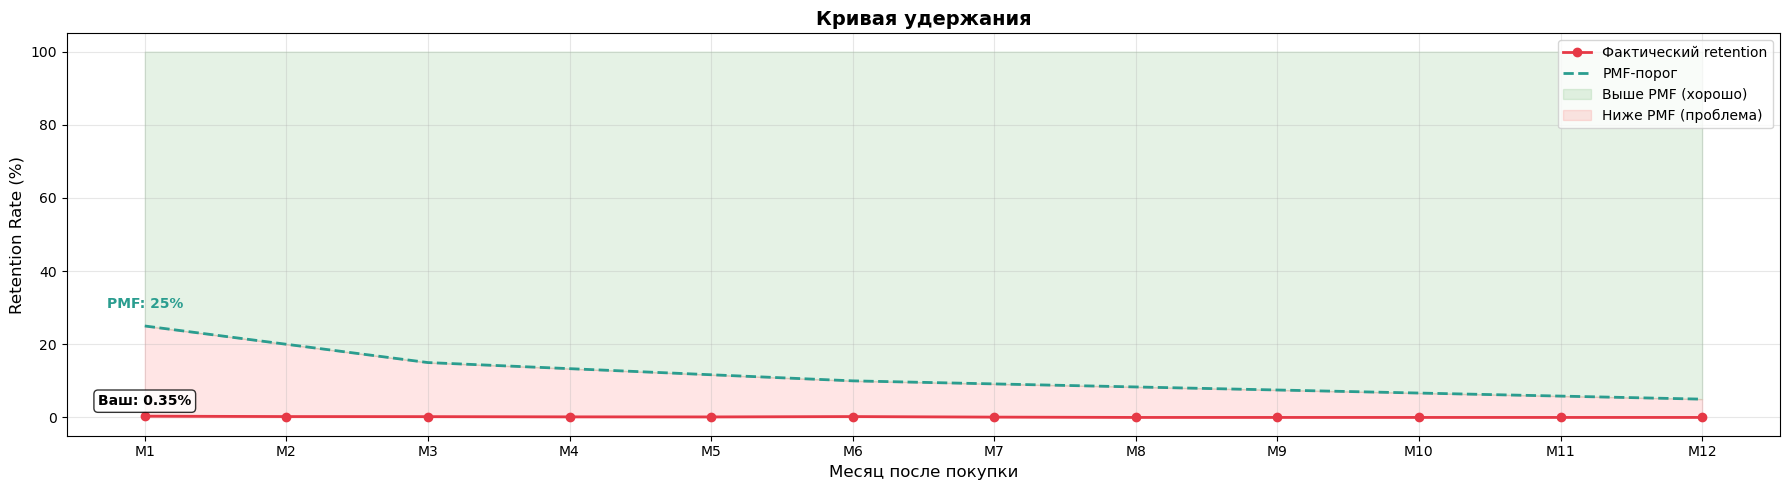

In [40]:
# ГРАФИК 1
fig, ax1 = plt.subplots(1, 1, figsize=(18, 5))
median_by_month = retention_matrix_filled.median()
months = [m for m in median_by_month.index if 1 <= m <= 12]
actual_values = median_by_month.loc[months].values

# PMF пороговые значения (сведения из открытых источников интернета по маркетплейсам)
pmf_thresholds = {
    1: 25.0,   # M1
    3: 15.0,   # M3
    6: 10.0,   # M6
    12: 5.0    # M12
}

# Интерполяция PMF порогов
pmf_curve = []
for month in months:
    if month in pmf_thresholds:
        pmf_curve.append(pmf_thresholds[month])
    elif month < 3:
        # Линейная интерполяция между M1 и M3
        pmf_curve.append(pmf_thresholds[1] - (pmf_thresholds[1] - pmf_thresholds[3]) * (month - 1) / 2)
    elif month < 6:
        # Линейная интерполяция между M3 и M6
        pmf_curve.append(pmf_thresholds[3] - (pmf_thresholds[3] - pmf_thresholds[6]) * (month - 3) / 3)
    else:
        # Линейная интерполяция между M6 и M12
        pmf_curve.append(pmf_thresholds[6] - (pmf_thresholds[6] - pmf_thresholds[12]) * (month - 6) / 6)

ax1.plot(months, actual_values, 'o-', linewidth=2, markersize=6,
         color='#E63946', label='Фактический retention', markerfacecolor='#E63946')
ax1.plot(months, pmf_curve, '--', linewidth=2, color='#2A9D8F', label='PMF-порог')
ax1.fill_between(months, pmf_curve, 100, alpha=0.1, color='green', label='Выше PMF (хорошо)')
ax1.fill_between(months, 0, pmf_curve, alpha=0.1, color='red', label='Ниже PMF (проблема)')
ax1.set_title('Кривая удержания', fontsize=14, fontweight='bold')
ax1.set_xlabel('Месяц после покупки', fontsize=12)
ax1.set_ylabel('Retention Rate (%)', fontsize=12)
ax1.set_xticks(months)
ax1.set_xticklabels([f'M{m}' for m in months])
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Добавляем аннотации
ax1.annotate(f'Ваш: {actual_values[0]:.2f}%', xy=(1, actual_values[0]),
             xytext=(1, actual_values[0] + 3), fontsize=10, fontweight='bold',
             ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax1.annotate(f'PMF: {pmf_curve[0]:.0f}%', xy=(1, pmf_curve[0]),
             xytext=(1, pmf_curve[0] + 5), fontsize=10, fontweight='bold',
             ha='center', color='#2A9D8F')


plt.tight_layout()
plt.show()

## Определение 5 основных метрик, на которых продакт-менеджер может сконцентрироваться, чтобы максимизировать прибыль компании

Предложение по пяти основным метрикам для продакт-менеджера следующие:

### Метрика 1. Месячный рост объема продаж 

Месячный рост объема продаж - общая стоимость всех проданных товаров через маркетплейс. Формула:

GMV = Σ(Цена товара × Количество) по всем заказам за период
Месячный рост GMV = (GMV текущий месяц / GMV предыдущий месяц - 1) × 100%

In [42]:
# Объединяем заказы с товарами для расчета GMV
orders_completed = orders[orders['order_status'] == 'delivered'].copy()
orders_completed['order_purchase_timestamp'] = pd.to_datetime(orders_completed['order_purchase_timestamp'])
# Объединяем с товарами
sales_data = pd.merge(
    orders_completed[['order_id', 'order_purchase_timestamp']],
    order_items[['order_id', 'price']],
    on='order_id',
    how='inner'
)
sales_data.head()
# Рассчитываем GMV по месяцам
sales_data['year_month'] = sales_data['order_purchase_timestamp'].dt.to_period('M')
monthly_gmv = sales_data.groupby('year_month')['price'].sum().reset_index()
monthly_gmv.columns = ['month', 'gmv']
monthly_gmv

,month,gmv
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


In [44]:
# Рассчитываем месячный рост GMV в %
threshold = monthly_gmv['gmv'].mean() * 0.1
real_start_idx = None
for i in range(len(monthly_gmv)):
    if monthly_gmv.loc[i, 'gmv'] > threshold:
        real_start_idx = i
        break
# Рассчитываем рост, начиная со второго месяца (исключая сильный выброс)
monthly_gmv = monthly_gmv.copy()
monthly_gmv['gmv_growth_pct'] = 0.0
monthly_gmv['is_real_growth'] = False
if real_start_idx is not None and real_start_idx < len(monthly_gmv) - 1:
    for i in range(real_start_idx + 1, len(monthly_gmv)):
        prev_gmv = monthly_gmv.loc[i-1, 'gmv']
        curr_gmv = monthly_gmv.loc[i, 'gmv']

        if prev_gmv > 0:  # Избегаем деления на 0
            growth = ((curr_gmv / prev_gmv) - 1) * 100
            monthly_gmv.loc[i, 'gmv_growth_pct'] = growth
            monthly_gmv.loc[i, 'is_real_growth'] = True
monthly_gmv

,month,gmv,gmv_growth_pct,is_real_growth
0,2016-09,134.97,0.000000,False
1,2016-10,40325.11,0.000000,False
2,2016-12,10.90,0.000000,False
3,2017-01,111798.36,0.000000,False
4,2017-02,234223.40,109.505220,True
5,2017-03,359198.85,53.357372,True
6,2017-04,340669.68,-5.158471,True
7,2017-05,489338.25,43.640094,True
8,2017-06,421923.37,-13.776744,True
9,2017-07,481604.52,14.145021,True


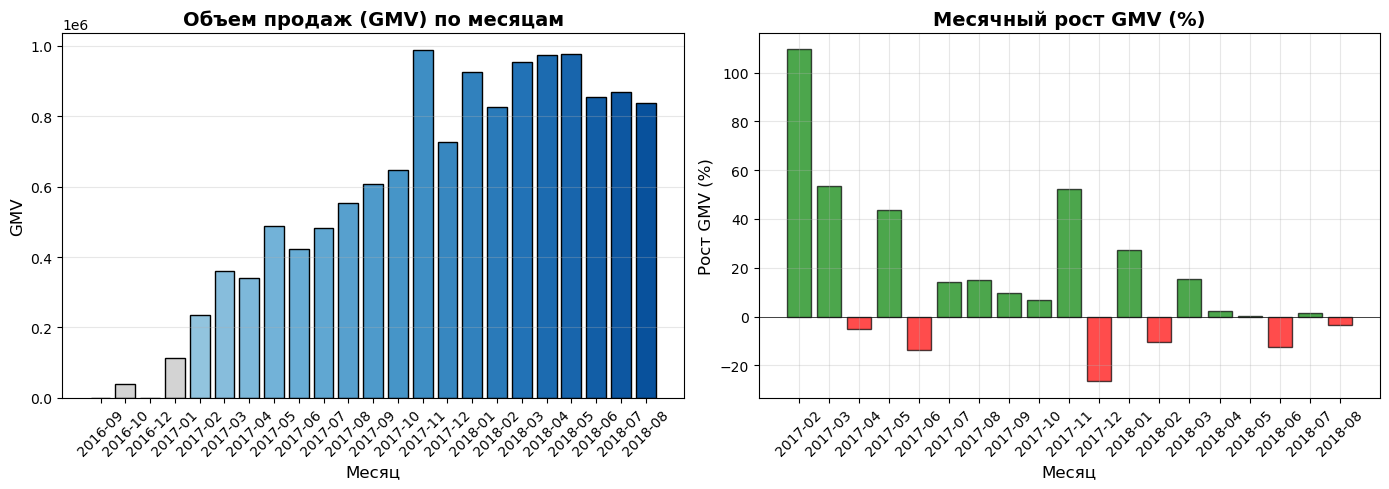

In [46]:
# Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Абсолютный GMV по месяцам
months = range(len(monthly_gmv))
colors = ['lightgray' if not monthly_gmv.loc[i, 'is_real_growth'] else
          plt.cm.Blues(0.3 + 0.6 * i/len(monthly_gmv)) for i in range(len(monthly_gmv))]

bars1 = ax1.bar(months, monthly_gmv['gmv'], color=colors, edgecolor='black')

ax1.set_title('Объем продаж (GMV) по месяцам', fontsize=14, fontweight='bold')
ax1.set_xlabel('Месяц', fontsize=12)
ax1.set_ylabel('GMV', fontsize=12)
ax1.set_xticks(months)
ax1.set_xticklabels([str(m) for m in monthly_gmv['month']], rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# График 2: Рост GMV в %
growth_data = monthly_gmv[monthly_gmv['is_real_growth']]
if len(growth_data) > 0:
    months_growth = range(len(growth_data))
    colors_growth = ['red' if x < 0 else 'green' for x in growth_data['gmv_growth_pct']]

    bars2 = ax2.bar(months_growth, growth_data['gmv_growth_pct'],
                    color=colors_growth, alpha=0.7, edgecolor='black')

    ax2.set_title('Месячный рост GMV (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Месяц', fontsize=12)
    ax2.set_ylabel('Рост GMV (%)', fontsize=12)
    ax2.set_xticks(months_growth)
    ax2.set_xticklabels([str(m) for m in growth_data['month']], rotation=45)
    ax2.axhline(y=0, color='black', linewidth=0.5)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
print(f"Всего месяцев с данными: {len(monthly_gmv)}")
print(f"Месяцев с расчетом роста: {len(growth_data)}")

# Средний GMV - абсолютные значения продаж
real_months_gmv = monthly_gmv[monthly_gmv['gmv'] > threshold]
if len(real_months_gmv) > 0:
    avg_gmv = real_months_gmv['gmv'].mean()
    print(f"\nСреднемесячный GMV: {avg_gmv:,.0f}")
    print(f"Медианный GMV: {real_months_gmv['gmv'].median():,.0f}")

    # Общий тренд
    if len(real_months_gmv) >= 2:
        first_real = real_months_gmv.iloc[0]['gmv']
        last_real = real_months_gmv.iloc[-1]['gmv']
        total_growth = ((last_real / first_real) - 1) * 100
        print(f"Общий рост за период: {total_growth:+.1f}%")

# Средний рост - относительное изменение
if len(growth_data) > 0:
    avg_growth = growth_data['gmv_growth_pct'].mean()
    median_growth = growth_data['gmv_growth_pct'].median()

    print(f"\nСреднемесячный рост GMV: {avg_growth:+.1f}%")
    print(f"Медианный рост GMV: {median_growth:+.1f}%")

    # Анализ последних 3 месяцев
    if len(growth_data) >= 3:
        recent_3 = growth_data.tail(3)
        recent_avg = recent_3['gmv_growth_pct'].mean()
        print("Последние 3 месяца:")
        for _, row in recent_3.iterrows():
            print(f"  {row['month']}: {row['gmv_growth_pct']:+.1f}%")
        print(f"  Средний рост: {recent_avg:+.1f}%")

    # Стабильность роста
    growth_std = growth_data['gmv_growth_pct'].std()
    print(f"\nВолатильность роста (std): {growth_std:.1f}%")
    print('Нестабильный бизнес, т.к. высокая волатильность')

# Смотрим на реальные цифры
print("\nАбсолютные значения GMV (последние 6 месяцев):")
last_6 = monthly_gmv.tail(6)
for _, row in last_6.iterrows():
    gmv_k = row['gmv'] / 1000
    growth = row['gmv_growth_pct'] if row['is_real_growth'] else "N/A"
    print(f"  {row['month']}: {gmv_k:,.0f}K (рост: {growth})")

print("Продажи стабильно растут")

Всего месяцев с данными: 23
Месяцев с расчетом роста: 19

Среднемесячный GMV: 659,051
Медианный GMV: 687,140
Общий рост за период: +650.1%

Среднемесячный рост GMV: +14.7%
Медианный рост GMV: +6.7%
Последние 3 месяца:
  2018-06: -12.4%
  2018-07: +1.4%
  2018-08: -3.4%
  Средний рост: -4.8%

Волатильность роста (std): 31.7%
Нестабильный бизнес, т.к. высокая волатильность

Абсолютные значения GMV (последние 6 месяцев):
  2018-03: 953K (рост: 15.35738356770102)
  2018-04: 974K (рост: 2.1165057658141917)
  2018-05: 978K (рост: 0.41196297502021917)
  2018-06: 856K (рост: -12.42570608204112)
  2018-07: 868K (рост: 1.3872102708041067)
  2018-08: 839K (рост: -3.3846077415256692)
Продажи стабильно растут


#### Вывод: 
GMV растет, но retention очень низкий. Мы привлекаем много новых клиентов, но они не возвращаются. Рост происходит за счет притока новых клиентов, а не удержания существующих

### Метрика 2. Active Paying Users (APU)

APU определяется как количество уникальных customer_unique_id с минимум 1 успешной покупкой за последние 30 дней

In [50]:
# Объединяем с информацией о пользователях
user_orders = pd.merge(
    orders_completed[['order_id', 'customer_id', 'order_purchase_timestamp']],
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='inner'
)
# Рассчитываем APU по месяцам (скользящее окно 30 дней)
# Сортируем по дате
user_orders = user_orders.sort_values('order_purchase_timestamp')
# Определяем диапазон дат
min_date = user_orders['order_purchase_timestamp'].min()
max_date = user_orders['order_purchase_timestamp'].max()

# Создаем список дат для анализа (первое число каждого месяца)
dates_range = pd.date_range(start=min_date, end=max_date, freq='MS')
apu_data = []
apu_growth = []
# Для каждого месяца считаем APU за предыдущие 30 дней
for current_date in dates_range:
    # Определяем период: 30 дней до текущей даты
    start_date = current_date - pd.Timedelta(days=30)

    # Фильтруем заказы за последние 30 дней
    recent_orders = user_orders[
        (user_orders['order_purchase_timestamp'] > start_date) &
        (user_orders['order_purchase_timestamp'] <= current_date)
    ]
    # Считаем уникальных платящих пользователей
    apu_count = recent_orders['customer_unique_id'].nunique()

    apu_data.append({
        'month': current_date.strftime('%Y-%m'),
        'apu': apu_count,
        'date': current_date
    })
# Создаем DataFrame
apu_df = pd.DataFrame(apu_data)
# Рассчитываем рост APU
apu_df = apu_df.sort_values('date').reset_index(drop=True)
apu_df['apu_growth_pct'] = apu_df['apu'].pct_change() * 100
apu_df.head()

,month,apu,date,apu_growth_pct
0,2016-10,1,2016-10-01 12:16:38,NaN
1,2016-11,262,2016-11-01 12:16:38,26100.0
2,2016-12,0,2016-12-01 12:16:38,-100.0
3,2017-01,1,2017-01-01 12:16:38,inf
4,2017-02,730,2017-02-01 12:16:38,72900.0


C:\Users\Vi\anaconda3\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\Vi\anaconda3\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


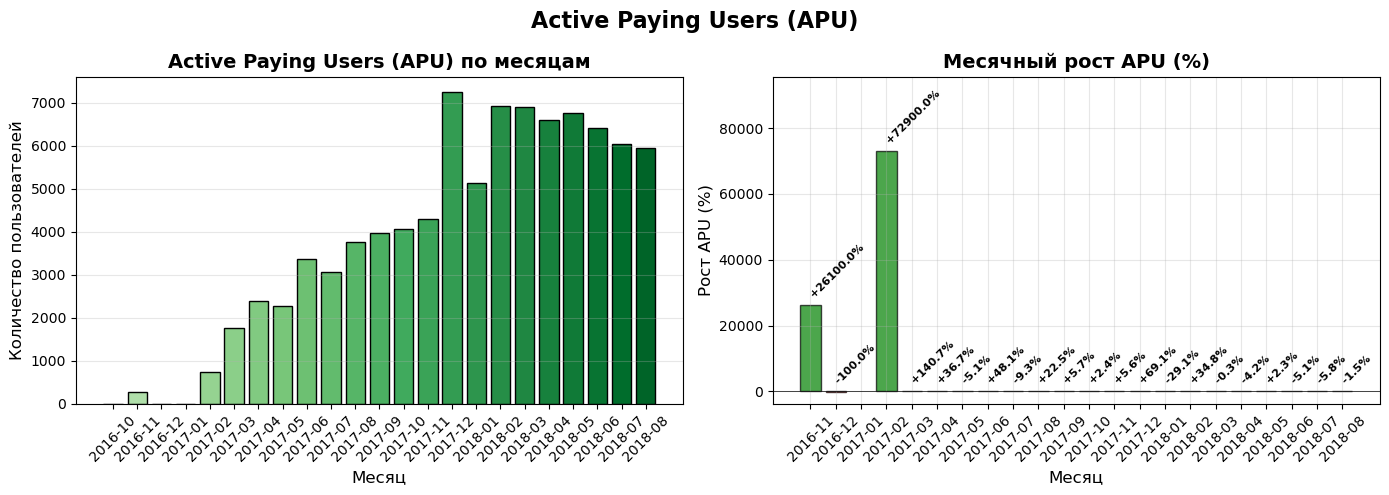

In [52]:
# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: APU по месяцам
months = range(len(apu_df))
bars1 = ax1.bar(months, apu_df['apu'],
                color=plt.cm.Greens(np.linspace(0.3, 0.9, len(apu_df))),
                edgecolor='black')

ax1.set_title('Active Paying Users (APU) по месяцам', fontsize=14, fontweight='bold')
ax1.set_xlabel('Месяц', fontsize=12)
ax1.set_ylabel('Количество пользователей', fontsize=12)
ax1.set_xticks(months)
ax1.set_xticklabels(apu_df['month'], rotation=45)
ax1.grid(True, alpha=0.3, axis='y')


# График 2: Рост APU
# Используем данные начиная со второго месяца
growth_data = apu_df.iloc[1:].copy()
months_growth = range(len(growth_data))

colors_growth = ['red' if x < 0 else 'green' for x in growth_data['apu_growth_pct']]
bars2 = ax2.bar(months_growth, growth_data['apu_growth_pct'],
                color=colors_growth, alpha=0.7, edgecolor='black')

ax2.set_title('Месячный рост APU (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Месяц', fontsize=12)
ax2.set_ylabel('Рост APU (%)', fontsize=12)
ax2.set_xticks(months_growth)
ax2.set_xticklabels(growth_data['month'], rotation=45)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.grid(True, alpha=0.3)
# Добавляем значения
for bar, growth in zip(bars2, growth_data['apu_growth_pct']):
    if pd.isna(growth) or np.isinf(growth):
        continue
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        growth,
        f'  {growth:+.1f}%',
        ha='left',
        va='bottom',
        fontsize=8,
        fontweight='bold',
        rotation=45,
        rotation_mode='anchor'
    )
y_min, y_max = ax2.get_ylim()
ax2.set_ylim(y_min, y_max * 1.25)


plt.suptitle('Active Paying Users (APU)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
print(f"Всего месяцев анализа: {len(apu_df)}")
print(f"Период: {apu_df.iloc[0]['month']} - {apu_df.iloc[-1]['month']}")

# Последние значения
last_apu = apu_df.iloc[-1]
print(f"\nТекущий APU ({last_apu['month']}): {last_apu['apu']:,.0f} пользователей")

# Сравнение с началом
if len(apu_df) > 1:
    first_apu = apu_df.iloc[0]
    total_growth = ((last_apu['apu'] / first_apu['apu']) - 1) * 100
    print(f"Начальный APU ({first_apu['month']}): {first_apu['apu']:,.0f} пользователей")
    print(f"Общий рост APU за период: {total_growth:+.1f}%")

# Средние значения
avg_apu = apu_df['apu'].mean()
print(f"\nСреднемесячный APU: {avg_apu:,.0f} пользователей")

# Тренд последних месяцев
if len(apu_df) >= 3:
    last_3 = apu_df.tail(3)
    avg_last_3 = last_3['apu'].mean()
    print("Последние 3 месяца:")
    for _, row in last_3.iterrows():
        growth = row['apu_growth_pct'] if 'apu_growth_pct' in row and not pd.isna(row['apu_growth_pct']) else "N/A"
        growth_str = f"{growth:+.1f}%" if isinstance(growth, (int, float)) else growth
        print(f"  {row['month']}: {row['apu']:,.0f} (рост: {growth_str})")

    print(f"Средний APU (последние 3 месяца): {avg_last_3:,.0f}")

# Сравнение с GMV (из метрики 1)
if 'monthly_gmv' in locals():
    print("Сравнение с GMV:")
    print(f"Среднемесячный GMV: {monthly_gmv['gmv'].mean():,.0f}")
    print(f"Среднемесячный APU: {avg_apu:,.0f}")
    if avg_apu > 0:
        avg_gmv_per_user = monthly_gmv['gmv'].mean() / avg_apu
        print(f"Средний GMV на пользователя: {avg_gmv_per_user:,.0f}")

Всего месяцев анализа: 23
Период: 2016-10 - 2018-08

Текущий APU (2018-08): 5,953 пользователей
Начальный APU (2016-10): 1 пользователей
Общий рост APU за период: +595200.0%

Среднемесячный APU: 3,824 пользователей
Последние 3 месяца:
  2018-06: 6,418 (рост: -5.1%)
  2018-07: 6,046 (рост: -5.8%)
  2018-08: 5,953 (рост: -1.5%)
Средний APU (последние 3 месяца): 6,139
Сравнение с GMV:
Среднемесячный GMV: 574,848
Среднемесячный APU: 3,824
Средний GMV на пользователя: 150


Комментарий: в начале периода наблюдается бхороший рост: с 1 до ~6,000 пользователей. Однако, последние 3 месяца наблюдается падение, т.е. пользователи приходят, но не возвращаются.

## Метрика 3. Activation Rate 
Activation Rate - доля новых пользователей, которые достигли ключевого действия, демонстрирующего понимание ценности продукта

In [56]:
# Смотрим распределение статусов заказов
status_distribution = orders['order_status'].value_counts()
status_percentage = orders['order_status'].value_counts(normalize=True) * 100
print("Распределение статусов заказов:")
for status, count in status_distribution.items():
    percentage = status_percentage[status]
    print(f"  • {status}: {count:>6,} заказов ({percentage:.1f}%)")

Распределение статусов заказов:
  • delivered: 96,478 заказов (97.0%)
  • shipped:  1,107 заказов (1.1%)
  • canceled:    625 заказов (0.6%)
  • unavailable:    609 заказов (0.6%)
  • invoiced:    314 заказов (0.3%)
  • processing:    301 заказов (0.3%)
  • created:      5 заказов (0.0%)
  • approved:      2 заказов (0.0%)


Комментарий: ключевое действие - это когда пользователь проявил намерение купить:
- заказ подтвержден (approved) - оплата прошла
- или выставлен счет (invoiced) - процесс оплаты начат
- или передан на сборку (processing) - товар готовится

In [58]:
# Определяем успешные статусы
successful_statuses = ['approved', 'invoiced', 'processing', 'shipped', 'delivered']
# Объединяем данные о пользователях и заказах
users_with_orders = pd.merge(
    customers[['customer_id', 'customer_unique_id']],
    orders[['customer_id', 'order_id', 'order_status', 'order_purchase_timestamp']],
    on='customer_id',
    how='inner'
)
users_with_orders.head()

,customer_id,customer_unique_id,order_id,order_status,order_purchase_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30


In [60]:
# Находим первый заказ каждого пользователя
users_first_order = users_with_orders.sort_values('order_purchase_timestamp') \
    .groupby('customer_unique_id').first().reset_index()
# Добавляем месяц первой покупки
users_first_order['first_month'] = pd.to_datetime(
    users_first_order['order_purchase_timestamp']
).dt.to_period('M')
# Анализируем по когортам
cohort_activation = users_first_order.groupby('first_month').agg({
    'customer_unique_id': 'count',
    'order_status': lambda x: x.isin(successful_statuses).sum()
}).reset_index()
cohort_activation.columns = ['cohort_month', 'total_users', 'activated_users']
cohort_activation['activation_rate'] = (cohort_activation['activated_users'] /
                                        cohort_activation['total_users']) * 100
cohort_activation.head()

,cohort_month,total_users,activated_users,activation_rate
0,2016-09,4,2,50.000000
1,2016-10,321,290,90.342679
2,2016-12,1,1,100.000000
3,2017-01,764,751,98.298429
4,2017-02,1752,1690,96.461187


In [62]:
total_users = cohort_activation['total_users'].sum()
total_activated = cohort_activation['activated_users'].sum()
overall_activation = (total_activated / total_users) * 100

print(f"Всего новых пользователей: {total_users:,}")
print(f"Активированных пользователей: {total_activated:,}")
print(f"Общий Activation Rate: {overall_activation:.1f}%")

# Медианный и средний Activation Rate
median_activation = cohort_activation['activation_rate'].median()
mean_activation = cohort_activation['activation_rate'].mean()

print(f"Медианный Activation Rate по когортам: {median_activation:.1f}%")
print(f"Средний Activation Rate по когортам: {mean_activation:.1f}%")

Всего новых пользователей: 96,096
Активированных пользователей: 94,937
Общий Activation Rate: 98.8%
Медианный Activation Rate по когортам: 98.6%
Средний Activation Rate по когортам: 88.5%


In [64]:
# Анализ динамики
if len(cohort_activation) >= 3:
    last_3 = cohort_activation.tail(3)
    first_3 = cohort_activation.head(3)

    avg_last_3 = last_3['activation_rate'].mean()
    avg_first_3 = first_3['activation_rate'].mean()

    print(f"Первые 3 когорты: {avg_first_3:.1f}%")
    print(f"Последние 3 когорты: {avg_last_3:.1f}%")

# Анализируем пользователей, которые не активировались
non_activated_users = users_first_order[
    ~users_first_order['order_status'].isin(successful_statuses)
]

if len(non_activated_users) > 0:
    non_activated_stats = non_activated_users['order_status'].value_counts()
    total_non_activated = len(non_activated_users)

    print(f"Всего не активировалось: {total_non_activated:,} пользователей")
    print("Причины неактивации:")

    for status, count in non_activated_stats.items():
        percentage = (count / total_non_activated) * 100
        print(f"  • {status}: {count:,} ({percentage:.1f}%)")

Первые 3 когорты: 80.1%
Последние 3 когорты: 33.0%
Всего не активировалось: 1,159 пользователей
Причины неактивации:
  • unavailable: 589 (50.8%)
  • canceled: 565 (48.7%)
  • created: 5 (0.4%)


### Выводы: 
Пользователи хотят покупать бразильские товары и успешно завершают покупки, но не возвращаются. Либо товары не соответствуют ожиданиям, либо дорогая/долгая доставка, либо товары часто недоступны

## Метрика 4. Repeat Purchase Rate (вовлеченность клиентов в использование продукта)

Repeat Purchase Rate (RPR) - доля повторных покупок клиентами

RPR = (Количество заказов от повторных клиентов / Общее количество заказов) × 100%

In [68]:
user_orders = user_orders.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
# Находим первый заказ каждого пользователя
first_orders = user_orders.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_orders.columns = ['customer_unique_id', 'first_order_date']
# Объединяем с основными данными
user_orders_with_first = pd.merge(
    user_orders,
    first_orders,
    on='customer_unique_id',
    how='left'
)
# Определяем тип заказа: первый или повторный
user_orders_with_first['is_first_order'] = (
    user_orders_with_first['order_purchase_timestamp'] ==
    user_orders_with_first['first_order_date']
)
user_orders_with_first['order_type'] = user_orders_with_first['is_first_order'].map({
    True: 'first',
    False: 'repeat'
})
# Рассчитываем RPR по месяцам
user_orders_with_first['order_month'] = pd.to_datetime(
    user_orders_with_first['order_purchase_timestamp']
).dt.to_period('M')
user_orders_with_first

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,first_order_date,is_first_order,order_type,order_month
0,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,2018-05-10 10:56:27,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,True,first,2018-05
1,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,2018-05-07 11:11:27,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,True,first,2018-05
2,b33ec3b699337181488304f362a6b734,9b3932a6253894a02c1df9d19004239f,2017-03-10 21:05:03,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,True,first,2017-03
3,41272756ecddd9a9ed0180413cc22fb6,914991f0c02ef0843c0e7010c819d642,2017-10-12 20:29:41,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,True,first,2017-10
4,d957021f1127559cd947b62533f484f7,47227568b10f5f58a524a75507e6992c,2017-11-14 19:45:42,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,True,first,2017-11
...,...,...,...,...,...,...,...,...
96473,725cf8e9c24e679a8a5a32cb92c9ce1e,74be082247cd677a147d83ee670e9d53,2017-06-08 21:00:36,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,True,first,2017-06
96474,c71b9252fd7b3b263aaa4cb09319a323,0ecf8e0a08148af0bf313184f167670a,2017-12-10 20:07:56,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,True,first,2017-12
96475,fdc45e6c7555e6cb3cc0daca2557dbe1,27f584b0f1dc4e610065c240f68b6be0,2017-02-07 15:49:16,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,True,first,2017-02
96476,94d3ee0bc2a0af9d4fa47a4d63616e8d,832a3b0254347d409512ae92eaf154a6,2018-05-02 15:17:41,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,True,first,2018-05


In [72]:
# Группируем по месяцам
monthly_stats = user_orders_with_first.groupby('order_month').agg({
    'order_id': 'count',
    'order_type': lambda x: (x == 'repeat').sum()
}).reset_index()
monthly_stats.columns = ['month', 'total_orders', 'repeat_orders']
monthly_stats['rpr'] = (monthly_stats['repeat_orders'] / monthly_stats['total_orders']) * 100
monthly_stats

,month,total_orders,repeat_orders,rpr
0,2016-09,1,0,0.000000
1,2016-10,265,3,1.132075
2,2016-12,1,0,0.000000
3,2017-01,750,28,3.733333
4,2017-02,1653,23,1.391410
5,2017-03,2546,37,1.453260
6,2017-04,2303,41,1.780287
7,2017-05,3546,81,2.284264
8,2017-06,3135,89,2.838915
9,2017-07,3872,104,2.685950


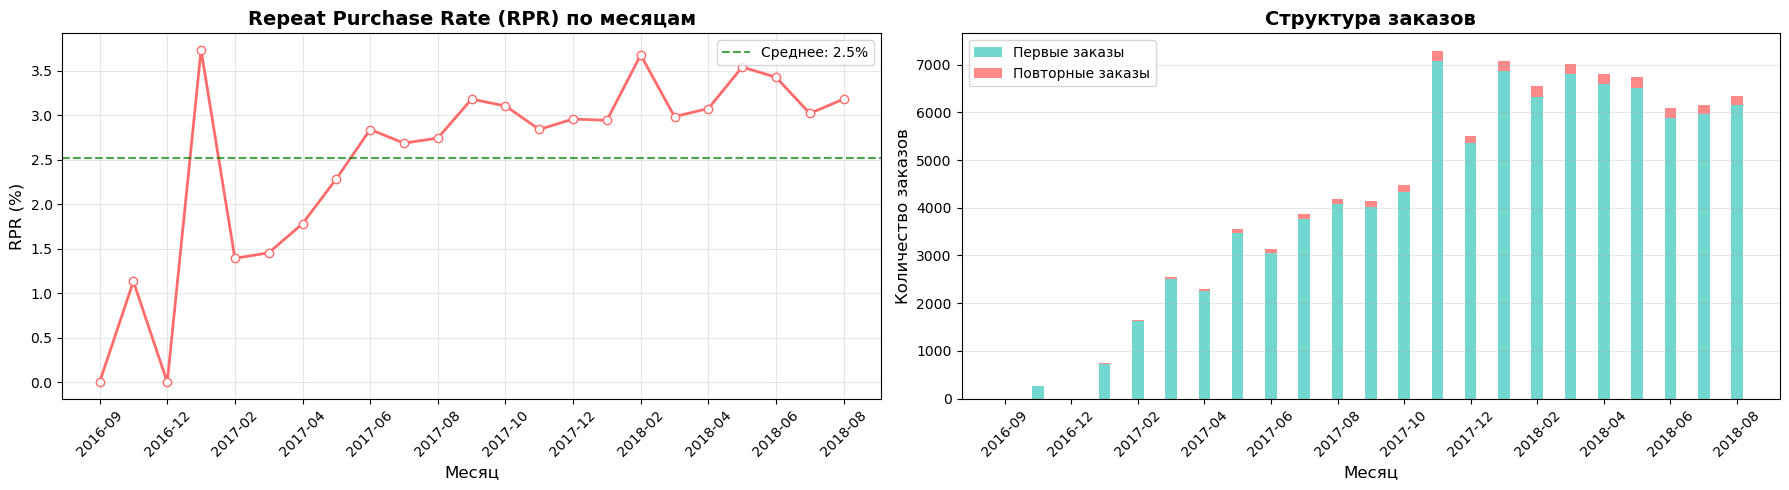

In [74]:
# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# График 1: RPR по месяцам
months = range(len(monthly_stats))
line = ax1.plot(months, monthly_stats['rpr'], 'o-', linewidth=2,
                color='#FF6B6B', markersize=6, markerfacecolor='white')

ax1.set_title('Repeat Purchase Rate (RPR) по месяцам', fontsize=14, fontweight='bold')
ax1.set_xlabel('Месяц', fontsize=12)
ax1.set_ylabel('RPR (%)', fontsize=12)
ax1.set_xticks(months[::2])
ax1.set_xticklabels([str(m) for m in monthly_stats['month'][::2]], rotation=45)
ax1.grid(True, alpha=0.3)

# Линия среднего значения
mean_rpr = monthly_stats['rpr'].mean()
ax1.axhline(y=mean_rpr, color='green', linestyle='--', alpha=0.7,
            label=f'Среднее: {mean_rpr:.1f}%')
ax1.legend()

# График 2: Структура заказов
x_pos = range(len(monthly_stats))
width = 0.35

first_orders_data = monthly_stats['total_orders'] - monthly_stats['repeat_orders']
repeat_orders_data = monthly_stats['repeat_orders']

bars1 = ax2.bar(x_pos, first_orders_data, width,
                color='#4ECDC4', label='Первые заказы', alpha=0.8)
bars2 = ax2.bar(x_pos, repeat_orders_data, width,
                bottom=first_orders_data, color='#FF6B6B',
                label='Повторные заказы', alpha=0.8)

ax2.set_title('Структура заказов', fontsize=14, fontweight='bold')
ax2.set_xlabel('Месяц', fontsize=12)
ax2.set_ylabel('Количество заказов', fontsize=12)
ax2.set_xticks(x_pos[::2])
ax2.set_xticklabels([str(m) for m in monthly_stats['month'][::2]], rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [76]:
user_order_counts = user_orders_with_first.groupby('customer_unique_id').size()
order_count_distribution = user_order_counts.value_counts().sort_index()

total_users = user_order_counts.count()
users_with_repeat = (user_order_counts > 1).sum()
repeat_rate = (users_with_repeat / total_users) * 100

print(f"Всего уникальных пользователей: {total_users:,}")
print(f"Пользователей с повторными заказами: {users_with_repeat:,} ({repeat_rate:.2f}%)")

# Среднее количество заказов на пользователя
avg_orders_per_user = user_order_counts.mean()
median_orders_per_user = user_order_counts.median()
print(f"Среднее количество заказов на пользователя: {avg_orders_per_user:.2f}")
print(f"Медианное количество заказов: {median_orders_per_user:.0f}")

# Распределение
print("Распределение пользователей по заказам:")
for count, num_users in order_count_distribution.head(10).items():
    percentage = (num_users / total_users) * 100
    print(f"  • {count} заказ: {num_users:,} пользователей ({percentage:.1f}%)")

Всего уникальных пользователей: 93,358
Пользователей с повторными заказами: 2,801 (3.00%)
Среднее количество заказов на пользователя: 1.03
Медианное количество заказов: 1
Распределение пользователей по заказам:
  • 1 заказ: 90,557 пользователей (97.0%)
  • 2 заказ: 2,573 пользователей (2.8%)
  • 3 заказ: 181 пользователей (0.2%)
  • 4 заказ: 28 пользователей (0.0%)
  • 5 заказ: 9 пользователей (0.0%)
  • 6 заказ: 5 пользователей (0.0%)
  • 7 заказ: 3 пользователей (0.0%)
  • 9 заказ: 1 пользователей (0.0%)
  • 15 заказ: 1 пользователей (0.0%)


### Вывод:
Отсутствие лояльной аудитории: 228 человек (0.2%) совершают 3+ заказов и практически не возвращаются


## Метрика 5. LTV 
Денежное выражение вовлеченности
 
LTV = Gross profit / число новых клиентов.

In [78]:
data_cohort['order_purchase_timestamp'] = pd.to_datetime(
    data_cohort['order_purchase_timestamp']
)
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)
data_cohort_with_order_id = pd.merge(
    data_cohort[['customer_unique_id', 'order_purchase_timestamp', 'C_month', 'periods_diff', 'customer_id']],
    orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_status']],
    on=['customer_id', 'order_purchase_timestamp'],
    how='left'
)
# Объединяем с ценами через order_id
data_cohort_with_price = pd.merge(
    data_cohort_with_order_id[['customer_unique_id', 'order_id', 'C_month', 'periods_diff']],
    order_items[['order_id', 'price']],
    on='order_id',
    how='left'
)
data_cohort_with_price = data_cohort_with_price.dropna(subset=['price'])
# Группируем по когортам и периодам
cohort_revenue = data_cohort_with_price.groupby(['C_month', 'periods_diff']).agg({
    'customer_unique_id': 'nunique',
    'price': 'sum'
}).reset_index()
cohort_revenue.columns = ['C_month', 'periods_diff', 'unique_users', 'period_revenue']
# Сортируем для кумулятивного расчета
cohort_revenue = cohort_revenue.sort_values(['C_month', 'periods_diff'])
# Расчет кумулятивной выручки по когортам
cohort_revenue['cumulative_revenue'] = cohort_revenue.groupby('C_month')['period_revenue'].cumsum()
# Находим размер каждой когорты (пользователи в период 0)
cohort_sizes = cohort_revenue[cohort_revenue['periods_diff'] == 0][['C_month', 'unique_users']]
cohort_sizes.columns = ['C_month', 'cohort_size']
cohort_sizes

,C_month,cohort_size
0,2016-09,1
1,2016-10,262
11,2016-12,1
12,2017-01,717
27,2017-02,1628
44,2017-03,2503
62,2017-04,2256
78,2017-05,3451
94,2017-06,3037
109,2017-07,3752


In [80]:
# Объединяем с кумулятивными данными
cohort_ltv = pd.merge(cohort_revenue, cohort_sizes, on='C_month', how='left')
cohort_ltv['cumulative_ltv'] = cohort_ltv['cumulative_revenue'] / cohort_ltv['cohort_size']
cohort_ltv

,C_month,periods_diff,unique_users,period_revenue,cumulative_revenue,cohort_size,cumulative_ltv
0,2016-09,0,1,134.97,134.97,1,134.970000
1,2016-10,0,262,40325.11,40325.11,262,153.912634
2,2016-10,6,1,99.99,40425.10,262,154.294275
3,2016-10,9,1,339.00,40764.10,262,155.588168
4,2016-10,11,1,49.00,40813.10,262,155.775191
...,...,...,...,...,...,...,...
209,2018-06,1,22,2032.04,833961.75,5878,141.878488
210,2018-06,2,6,748.70,834710.45,5878,142.005861
211,2018-07,0,5949,851282.06,851282.06,5949,143.096665
212,2018-07,1,6,365.37,851647.43,5949,143.158082


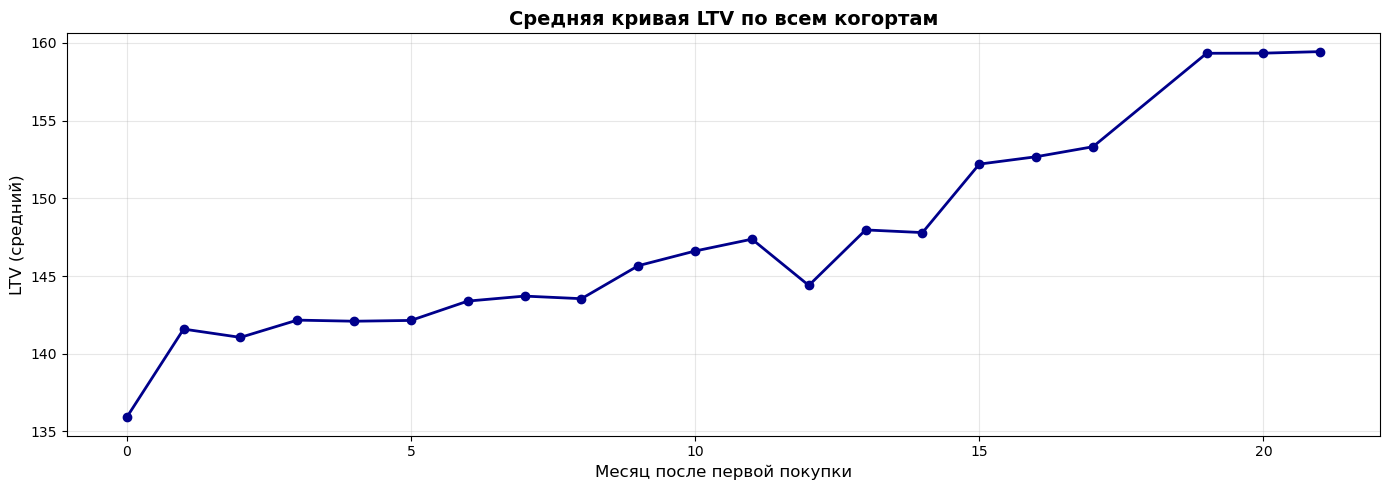

In [82]:
fig, (ax1) = plt.subplots(1, figsize=(14, 5))

# График 1: Средняя кривая LTV по всем когортам
avg_ltv_by_period = cohort_ltv.groupby('periods_diff')['cumulative_ltv'].mean().reset_index()
avg_ltv_by_period = avg_ltv_by_period.sort_values('periods_diff')

ax1.plot(avg_ltv_by_period['periods_diff'], avg_ltv_by_period['cumulative_ltv'],
         'o-', linewidth=2, markersize=6, color='darkblue')

ax1.set_title('Средняя кривая LTV по всем когортам', fontsize=14, fontweight='bold')
ax1.set_xlabel('Месяц после первой покупки', fontsize=12)
ax1.set_ylabel('LTV (средний)', fontsize=12)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод:
LTV растет, но медленно для масштабирования

## Приоритизация гипотез: фреймворк ICE

После когортного анализа были сформулированы 3 продуктовые гипотезы. 
Команда заполнила Confidence и Ease, моя задача — рассчитать Impact 
на данных и выбрать гипотезу с максимальным ICE-баллом.

### Методология расчёта Impact

**Период данных:** когорты с июня 2017 (стабильная фаза, исключаем ранний шум).

**Допущение:** конверсия в повторный заказ равна медианному retention M1 
(рассчитан в части 1 проекта).
**Формула:** определяется через функцию ниже

In [84]:
# Определение Impact
impact_scale = [
    (50, 1), (150, 2), (350, 3), (750, 4), (1550, 5),
    (3150, 6), (6350, 7), (12750, 8), (25550, 9), (51150, 10),
]


def get_impact(metric):
    for upper, score in impact_scale:
        if metric <= upper:
            return score
    return 10

In [86]:
retention_matrix_nonz = retention_matrix.fillna(0)
retention_matrix_nonz

periods_diff,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,19,20,21
C_month,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-10,262.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,1.0,1.0
2016-12,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01,717.0,2.0,0.0,4.0,1.0,1.0,2.0,2.0,0.0,0.0,...,4.0,3.0,2.0,0.0,2.0,2.0,2.0,1.0,0.0,0.0
2017-02,1628.0,2.0,3.0,6.0,4.0,2.0,4.0,1.0,2.0,5.0,...,6.0,1.0,3.0,2.0,1.0,1.0,3.0,0.0,0.0,0.0
2017-03,2503.0,7.0,13.0,11.0,3.0,2.0,9.0,4.0,7.0,6.0,...,4.0,4.0,3.0,7.0,2.0,3.0,2.0,0.0,0.0,0.0
2017-04,2256.0,8.0,6.0,1.0,6.0,8.0,6.0,10.0,6.0,5.0,...,3.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0
2017-05,3451.0,15.0,13.0,8.0,13.0,11.0,11.0,4.0,10.0,9.0,...,11.0,6.0,3.0,7.0,4.0,0.0,0.0,0.0,0.0,0.0
2017-06,3037.0,13.0,16.0,10.0,6.0,15.0,9.0,6.0,4.0,10.0,...,8.0,3.0,9.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0


In [88]:
# Когорты с июня 2017 и позже
cohorts_june_2017 = [
    '2017-06', '2017-07', '2017-08', '2017-09', '2017-10',
    '2017-11', '2017-12', '2018-01', '2018-02', '2018-03',
    '2018-04', '2018-05', '2018-06', '2018-07', '2018-08'
]
# Берем данные только для этих когорт
retention_matrix_nonz = retention_matrix.fillna(0)
cohorts_data = retention_matrix_nonz.loc[cohorts_june_2017]

# Суммируем пользователей в месяц 0 (первые покупки)
total_users_june_2017 = cohorts_data[0].sum()
avg_cohort_size = cohorts_data[0].mean()

print(f"Когорт с июня 2017: {len(cohorts_june_2017)}")
print(f"Общее количество пользователей: {total_users_june_2017:,.0f}")
print(f"Средний размер когорты: {avg_cohort_size:,.0f}")

Когорт с июня 2017: 15
Общее количество пользователей: 82,539
Средний размер когорты: 5,503


### Гипотеза 1. Исправить баг в процессинге → убрать отмены
50.8% отмен связаны со статусом `unavailable`. Если их убрать, 
эти пользователи получат доставленный первый заказ, и часть из них 
сконвертируется в повторный заказ по обычному retention M1.

In [90]:
# Найти уникальных пользователей с unavailable заказами С ИЮНЯ 2017
unavailable_users_june_2017 = users_with_orders[
    (users_with_orders['order_status'] == 'unavailable') &
    (pd.to_datetime(users_with_orders['order_purchase_timestamp']).dt.to_period('M') >= '2017-06')
]['customer_unique_id'].nunique()
print(f"Уникальных пользователей с unavailable заказами с июня 2017: {unavailable_users_june_2017}")
# Тогда расчет Impact:
additional_repeat = unavailable_users_june_2017 * median_month1_retention/100  # 0.35%
print(f"Дополнительных повторных заказов: {additional_repeat}")
# Расчет ICE
impact_1 = get_impact(additional_repeat)
conf_1 = 8
ease_1 = 6
ICE_1 = impact_1*conf_1*ease_1
print('Гипотеза 1')
print('Impact =', impact_1)
print('Confidence=', conf_1)
print('Ease=', ease_1)
print('ICE=', ICE_1)

Уникальных пользователей с unavailable заказами с июня 2017: 470
Дополнительных повторных заказов: 1.645
Гипотеза 1
Impact = 1
Confidence= 8
Ease= 6
ICE= 48


### Гипотеза 2. Сократить время до отгрузки

Tсли клиенты перестанут получать заказы с запаздыванием, 
часть из них вернётся за повторной покупкой по обычному retention M1. 
В качестве базы берём всех пользователей когорт с июня 2017.


In [92]:
repeat_orders = total_users_june_2017 * median_month1_retention/100
print('Дополнительных повторных заказов: ', repeat_orders)
impact_2 = get_impact(repeat_orders)
conf_2 = 10
ease_2 = 4
ICE_2 = impact_2*conf_2*ease_2
print('Гипотеза 2')
print('Impact =', impact_2)
print('Confidence=', conf_2)
print('Ease=', ease_2)
print('ICE=', ICE_2)

Дополнительных повторных заказов:  288.88649999999996
Гипотеза 2
Impact = 3
Confidence= 10
Ease= 4
ICE= 120


### Гипотеза 3. Новый способ оплаты

Новый способ оплаты должен конвертировать в повторный заказ 
тех клиентов, которые ранее сделали только один заказ. Базой для расчёта 
служат пользователи с единственным заказом (без повторных покупок) 
из когорт с июня 2017.

In [98]:
# Фильтруем данные с июня 2017
data_cohort['order_purchase_timestamp'] = pd.to_datetime(data_cohort['order_purchase_timestamp'])
data_filtered = data_cohort[data_cohort['order_purchase_timestamp'] >= '2017-06-01']
print(f"Данных с июня 2017: {len(data_filtered)} записей")
# Находим пользователей, которые не делали повторный заказ
# Группируем по пользователям и считаем количество заказов
user_stats = data_filtered.groupby('customer_unique_id').agg(
    total_orders=('order_purchase_timestamp', 'count'),  # считаем по timestamp
    max_period=('periods_diff', 'max')
).reset_index()
print(f"Всего уникальных пользователей с июня 2017: {len(user_stats)}")
# Пользователи без повторных заказов (только 1 заказ и periods_diff = 0)
one_time_users = user_stats[
    (user_stats['total_orders'] == 1) &
    (user_stats['max_period'] == 0)
]
num_one_time_users = len(one_time_users)
print(f"Пользователей без повторных заказов: {num_one_time_users}")
additional_orders = num_one_time_users * median_month1_retention/100
print("Дополнительные заказы ", additional_orders)
# Расчет ICE
impact_3 = get_impact(additional_orders)
conf_3 = 5
ease_3 = 9
ICE_3 = impact_3*conf_3*ease_3
print('Гипотеза 3')
print('Impact =', impact_3)
print('Confidence=', conf_3)
print('Ease=', ease_3)
print('ICE=', ICE_3)

Данных с июня 2017: 85413 записей
Всего уникальных пользователей с июня 2017: 82863
Пользователей без повторных заказов: 80281
Дополнительные заказы  280.9835
Гипотеза 3
Impact = 3
Confidence= 5
Ease= 9
ICE= 135


### Вывод: 
Выбираем **гипотезу 3** (новый способ оплаты), ICE = 135.

Гипотеза имеет средний Impact, но выигрывает за счёт высокой 
лёгкости реализации (Ease = 9). Это разумная ставка для команды: 
быстрый эксперимент с понятной механикой, не требующий 
инфраструктурных изменений как в гипотезах 1 и 2.

In [281]:
results = pd.DataFrame({
    'Гипотеза': [
        'Исправить баг процессинга',
        'Сократить время отгрузки',
        'Новый способ оплаты',
    ],
    'Impact_метрика': [additional_repeat, repeat_orders, additional_orders],
    'Impact': [impact_1, impact_2, impact_3],
    'Confidence': [8, 10, 5],
    'Ease': [6, 4, 9],
})
results['ICE'] = results['Impact'] * results['Confidence'] * results['Ease']
results = results.sort_values('ICE', ascending=False).reset_index(drop=True)
results

,Гипотеза,Impact_метрика,Impact,Confidence,Ease,ICE
0,Новый способ оплаты,280.9835,3,5,9,135
1,Сократить время отгрузки,288.8865,3,10,4,120
2,Исправить баг процессинга,1.6450,1,8,6,48


## Метрики A/B-теста

**Гипотеза:** новый способ оплаты снизит трение при оформлении заказа 
и увеличит конверсию в повторный заказ среди пользователей, ранее 
сделавших только одну покупку.

### Иерархия метрик

| Тип | Метрика | Направление | Зачем |
|-----|---------|-------------|-------|
| **Целевая (основная)** | Конверсия в повторный заказ за 30 дней | ↑ | Прямое отражение гипотезы: новый способ оплаты должен возвращать пользователей. |
| Целевая | Общее количество повторных заказов | ↑ | Абсолютный прирост — то, что важно бизнесу. |
| Целевая | LTV пользователя | ↑ | Подтверждает, что эффект устойчив, а не разовый. |
| **Прокси (основная)** | Конверсия на этапе оплаты | ↑ | Реагирует быстрее целевой: если новый способ работает, рост виден сразу, не нужно ждать 30 дней. |
| Прокси | Время оформления заказа | ↓ | Прямой индикатор снижения трения. |
| Прокси | Bounce rate на странице оплаты | ↓ | Показывает, что пользователи не уходят с этапа оплаты. |
| **Guardrail (основная)** | NPS пользователей нового способа | не ухудшать | Защита от ситуации «конверсия выросла, но опыт стал хуже». |
| Guardrail | Обращения в поддержку по оплате | не увеличивать | Контроль скрытых проблем UX/технических багов. |
| Guardrail | Доля отмен после успешной оплаты | не увеличивать | Защищает от ложного роста — оплачено ≠ доставлено. |
### Логика выбора

**Целевые** напрямую измеряют гипотезу: гипотеза о повторных заказах → 
основная метрика именно про повторные заказы. LTV добавлен как 
проверка на долговечность эффекта.

**Прокси** нужны, чтобы не ждать 30 дней до оценки. Конверсия на этапе 
оплаты — самая ранняя точка, где виден эффект; если она не растёт, 
дальше можно не ждать.

**Guardrail** защищают от типичных ловушек A/B-тестов:
- NPS — против ухудшения опыта ради метрики;
- обращения в поддержку — против скрытых багов;
- отмены после оплаты — против ложного роста (оплата прошла, заказ не дошёл).

### Критерии успеха

Тест считается успешным при одновременном выполнении:

1. Конверсия в повторный заказ выросла **минимум на 10%** при p-value < 0.05.
2. Конверсия на этапе оплаты выросла, NPS не упал.
3. Время оформления снизилось, обращения в поддержку не выросли.

# Итоговый отчёт: анализ маркетплейса

## 1. Формализация проблемы

**Гипотеза:** маркетплейс находится в стадии стагнации роста, замаскированной 
притоком новых пользователей. Бизнес-модель не масштабируется, так как опирается 
исключительно на привлечение, а не на удержание.

**На чём основана гипотеза:**

| Метрика                        | Значение      | Бенчмарк       | Оценка     |
|--------------------------------|---------------|----------------|------------|
| Retention (M1)                 | 0.35%         | 20–40%         | критично   |
| Доля пользователей с 3+ заказами | 0.2%        | 5–15%          | критично   |
| Рост GMV за период             | +650%         | —              | вводит в заблуждение |
| Лучшая когорта (M3 retention)  | 0.56%         | —              | критично   |
| Доля отмен (unavailable)       | 50.8% от отмен| —              | требует внимания |

GMV растёт, но рост не транслируется в LTV — каждый новый пользователь делает 
один заказ и уходит.

---

## 2. Выводы

**Что работает:**
- Привлечение и активация: пользователи находят продукт, регистрируются, 
  совершают первый заказ. 

**Что не работает:**
- **Retention.** Только 0.35% пользователей возвращаются на второй месяц. 
  Когортный анализ не показывает улучшения retention между когортами.
- **Лояльная база отсутствует.** 97% пользователей делают ровно 1 заказ. 
  3+ заказов — у 0.2%. Получается, что маркетплейс работает как разовая транзакционная площадка.
- **APU вышел на плато.** Рост Active Paying Users замедлился, при этом 
  GMV растёт за счёт привлечения, а не углубления отношений с клиентами.
- **Логистика как фактор риска.** 50.8% отмен связаны со статусом 
  `unavailable` — товар отсутствует. Это бьёт и по retention, 
  и по NPS, и по unit-экономике.

Таким образом, product/market fit не достигнут. Признаки — низкий retention, 
быстрая потеря пользователей, отсутствие растущих когорт.

---

## 3. Рекомендации

### Приоритет 1: A/B-тест нового способа оплаты

Выбор обоснован через ICE-фреймворк (наивысший балл среди 3 гипотез):

| Параметр    | Балл | Обоснование                                  |
|-------------|------|----------------------------------------------|
| Impact      | 3    | средний потенциал роста повторных заказов    |
| Confidence  | 5    | умеренная уверенность в эффекте              |
| Ease        | 9    | низкая стоимость реализации                  |
| **ICE**     | **135** | максимум среди рассмотренных гипотез      |

**Гипотеза:** упрощение этапа оплаты снизит трение при повторном заказе 
и увеличит конверсию в R1 (return rate первого месяца).

**Метрики теста:**

- *Целевая:* конверсия в повторный заказ за 30 дней, LTV
- *Прокси:* конверсия на этапе оплаты, время оформления, bounce rate на оплате
- *Guardrail:* NPS (Net Promoter Score), обращения в поддержку по оплате, доля отмен после оплаты

### Приоритет 2: Разобраться с `unavailable`

Половина отмен — отсутствие товара. Это не A/B-тест, это операционная задача: 
аудит интеграции с поставщиками, синхронизация остатков, корректное скрытие 
отсутствие позиций из выдачи. Это принесет дешевую победу с прямым эффектом на retention.

### Приоритет 3: Дальнейшее исследование

Низкий retention — симптом, а не причина. Чтобы понять, *почему* 
пользователи не возвращаются, нужно:
- сегментировать пользователей по категориям первой покупки и сравнить retention,
- проанализировать NPS (Net Promoter Score)/ отзывы по статусу заказа,
- провести customer development с теми, кто сделал 1 заказ и не вернулся.

---

## Ограничения анализа

- Данные не содержат маркетинговых каналов — нельзя оценить, какие 
  источники привлечения дают пользователей с лучшим retention.
- Нет данных о просмотрах/корзинах — воронка анализируется только 
  до уровня заказа.
- Период данных ограничен ~24 месяцами, сезонность оценивается приблизительно.